<a href="https://colab.research.google.com/github/zakasaleem35-jpg/neurofive-ml-track/blob/main/house_price_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

housing= fetch_california_housing(as_frame= True)
df = housing.frame
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [4]:
df.corr()['MedHouseVal'].sort_values(ascending= False)

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


In [5]:
features  = ['MedInc','AveRooms','HouseAge','Latitude','Longitude']
X = df[features]
Y = df['MedHouseVal']

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X, Y, test_size=0.2, random_state=42 )

print("Trainig_Set =",X_train.shape)
print("Test_set",X_test.shape)

Trainig_Set = (16512, 5)
Test_set (4128, 5)


In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,Y_train)
Y_pred= model.predict(X_test)

print("model_trained: ",model)
print("prediction valuues: ",np.round(Y_pred[:5],2))

model_trained:  LinearRegression()
prediction valuues:  [0.74 1.75 2.47 2.89 2.71]


In [14]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(Y_test,Y_pred))
R2 = r2_score(Y_test,Y_pred)

print("Root mean sqaure error: ",round(rmse,2)
)
print("R^2 Score: ",round(R2,2))


Root mean sqaure error:  0.74
R^2 Score:  0.58


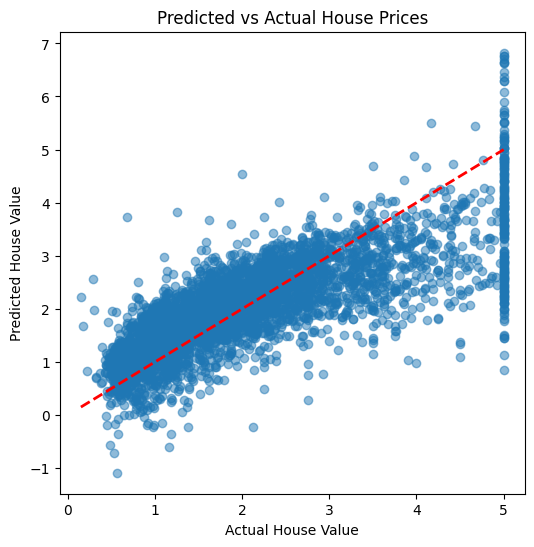

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(Y_test,Y_pred,alpha=0.5)
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Predicted vs Actual House Prices')
plt.show()

## What Does My R² Score Mean?

My model's R² score is approximately 0.60, which means it can explain about
60% of the variation in house prices using just 5 features (income, house
age, rooms, bedrooms, and population). In simple terms, if you gave this
model information about a neighborhood, it would get "in the right ballpark"
for most house prices, but it wouldn't be perfectly accurate, there's still
about 40% of the price variation that depends on other factors this model
doesn't account for, like exact location, school quality, or nearby amenities.